In [35]:
from python_model.bpsk.dsp import tx  
import matplotlib.pyplot as plt
import numpy as np

[INFO] dsp.py:137: Header:[0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[INFO] dsp.py:138: Version:[0, 0, 0, 1]
Length:[0, 0, 0, 0, 1, 1, 0, 0]
[INFO] dsp.py:139: Flags:[1, 0]
packetID:[0, 0, 0, 0, 0, 0, 0, 1]
[INFO] dsp.py:143: [-1, -1, -1, 1, -1, -1, -1, -1, 1, 1, -1, -1, 1, -1, -1, -1, -1, -1, -1, -1, -1, 1]


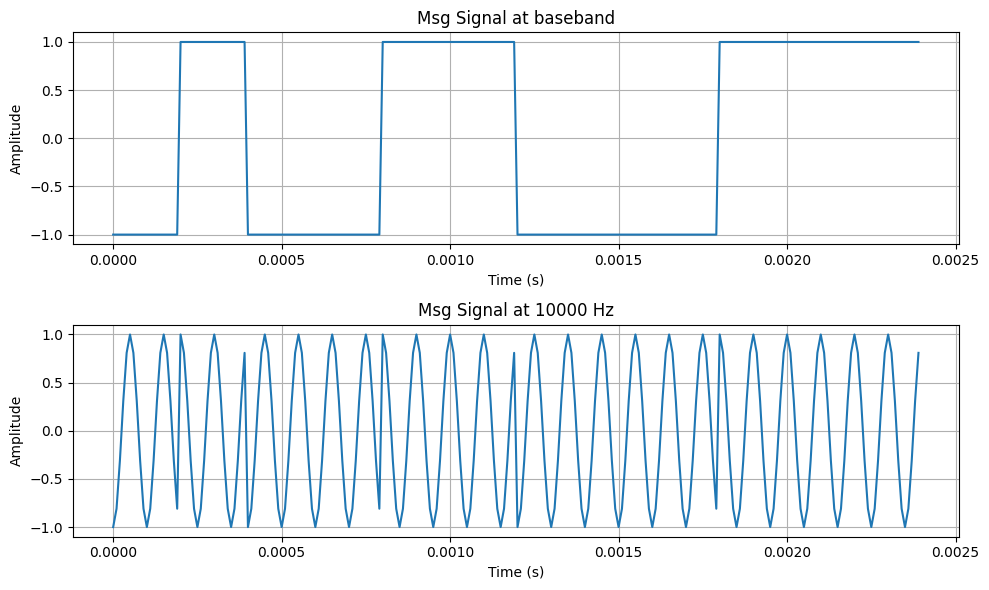

In [36]:
wave = tx('13',5,20,10000,100000)
msg = '010011000111'
(header,baseband_header) = wave.generate_header(1,len(msg),2,1)  
(passband,baseband,time) = wave.packetize(msg,baseband_header)    
wave.bpsk_modulation(msg,True)




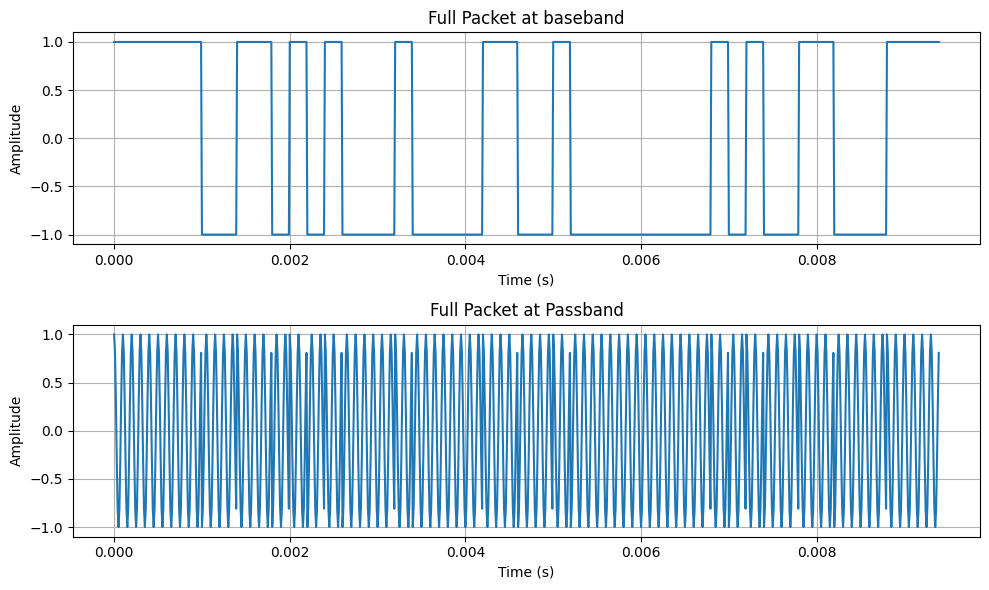

In [37]:
fig,ax = plt.subplots(nrows=2,ncols=1,figsize=(10,6))

ax[0].plot(time,baseband)
ax[1].plot(time,np.real(passband))

ax[0].set_title(f"Full Packet at baseband")
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Amplitude')
ax[0].grid(True)

ax[1].set_title(f"Full Packet at Passband")
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Amplitude')
ax[1].grid(True)
plt.tight_layout()
plt.show()

C:\Users\khitchcock\AppData\Local\Temp\ipykernel_39252\2100674277.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  gate[delaySamples:delaySamples+len(passband)] = passband


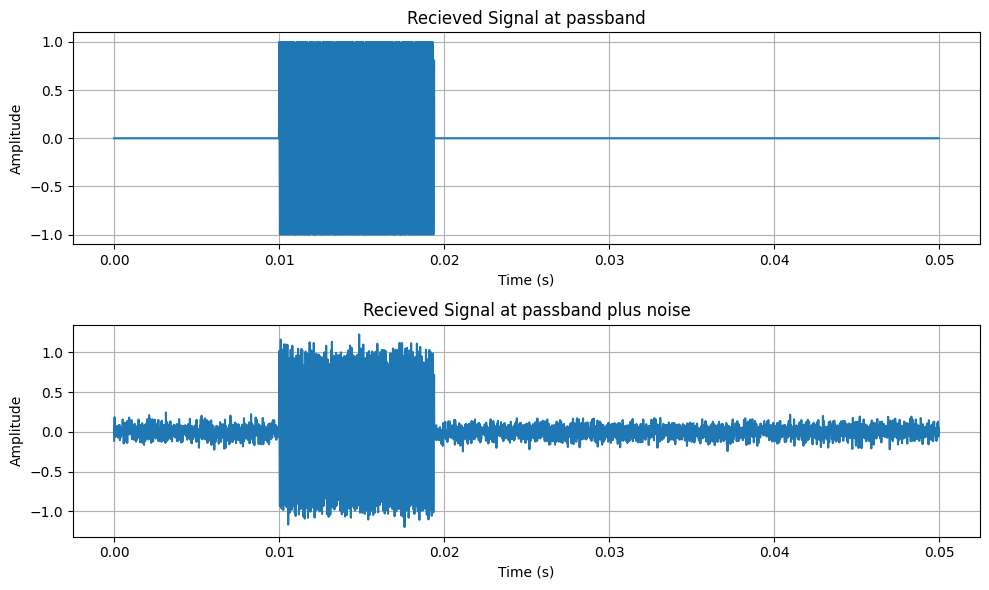

In [43]:
#Simulate signal in a given amount of time
gateLen = 5000 #samples
delaySamples = 1000
gateTime = np.arange(0,gateLen-1)/wave.sampleRate

gate = np.zeros(gateLen-1)
gate[delaySamples:delaySamples+len(passband)] = passband
#Lets start with 20 dB 
rx_signal = gate
rx_signal = wave.add_awgn_noise(gate,10,True)
#This should be at passband now.
fig,ax = plt.subplots(nrows=2,ncols=1,figsize=(10,6))

ax[0].plot(gateTime,np.real(gate))
ax[0].set_title(f"Recieved Signal at passband")
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Amplitude')
ax[0].grid(True)


ax[1].plot(gateTime,np.real(rx_signal))
ax[1].set_title(f"Recieved Signal at passband plus noise")
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Amplitude')
ax[1].grid(True)
plt.tight_layout()
plt.show()


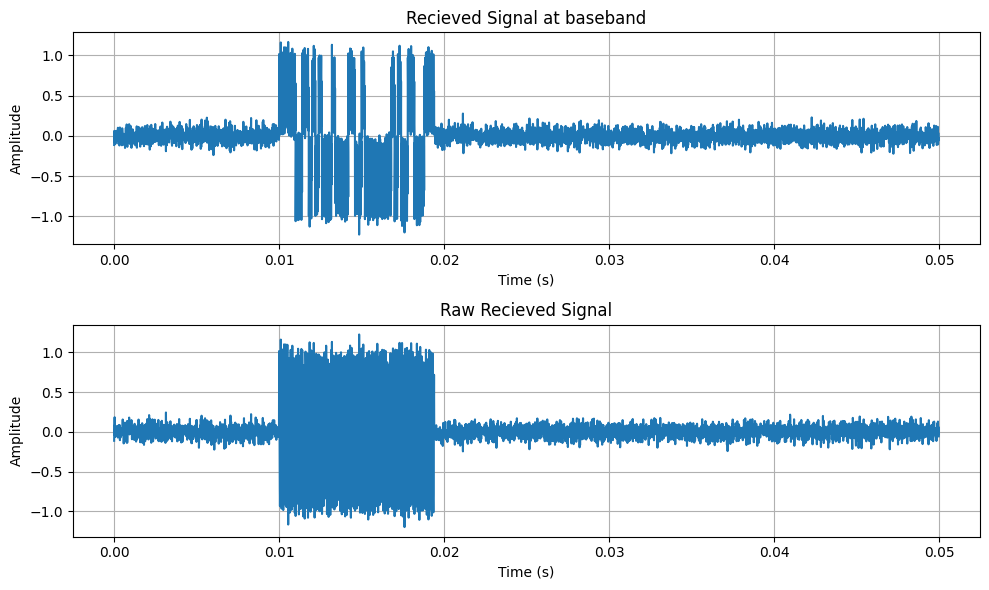

In [44]:
#Need to DDC signal
#We must multiple out the carrier frequecy using the conjugate of the carrier
msg_time = np.arange(0,len(rx_signal))/wave.sampleRate
DDC = rx_signal * np.exp(-1j*2*np.pi*wave.carrier_frequency*msg_time)

#This should be at baseband now.
fig,ax = plt.subplots(nrows=2,ncols=1,figsize=(10,6))

ax[0].plot(msg_time,np.real(DDC))
ax[0].set_title(f"Recieved Signal at baseband")
ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Amplitude')
ax[0].grid(True)


ax[1].plot(msg_time,np.real(rx_signal))
ax[1].set_title(f"Raw Recieved Signal")
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Amplitude')
ax[1].grid(True)
plt.tight_layout()
plt.show()

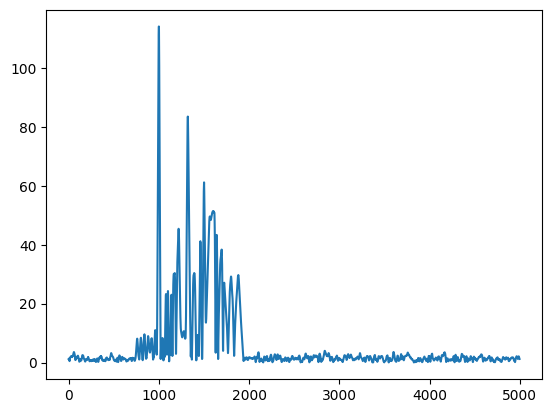

In [47]:
#Lets try and produce a match filter output
window_size = 10
lpf_kernel = np.ones(window_size) / window_size
DDC_filtered = np.convolve(DDC, lpf_kernel, mode='same')

fft_len = len(DDC_filtered)

#We need to pad the match filter so rx_signal is the same size as matchfilter
matchfilter = np.zeros(fft_len,dtype=complex)
matchfilter[:len(wave.baseband_chips)]=wave.baseband_chips


X=np.fft.fft(DDC_filtered,n=fft_len)
H=np.fft.fft(matchfilter,n=fft_len)
matchFilter = np.fft.ifft(X*np.conj(H))

plt.plot(np.abs(matchFilter))
# plt.plot(20*np.log10(np.abs(matchFilter)))

In [ ]:
#we need to find the peak energy to start our message decoding
peak = np.argmax(np.abs(matchfilter))

#we then need to use this as the starting point for our message and remove the rest of the gate.
#Steps to get message
#step 1: grab header, this can be done besause we know how long the header should break
#Header is made up of 4 fields with the following size
#Version: 2-bits
#Lenght: 8-bits
#Flags: 2-bits
#packetID: 8-bits
#With each section have the same chip length we can find it like the following
header_length = wave.chips_per_symbol *(wave.msg_field_length+
        wave.version_field_length+
        wave.pack_ID_field_length+
        wave.flag_field_length)

print(header_length)

header = rx_signal[peak:peak+header_length]


440
